# 02 · Streaming feature store + hourly graph features

`src/features/store.py` replays transactions in time order: **compute features from the past, then update
state**. Graph features (`src/features/graph.py`) come from 24 h snapshots rebuilt once per hour, so a
transaction never sees a snapshot newer than the start of its hour.

In [1]:
# --- setup: find the repo root (works locally, in Colab and on Kaggle) -------------------------
import os, sys, shutil, subprocess
from pathlib import Path

REPO_URL = ""          # optional: your GitHub repo URL, cloned if the code is not found
ROOT = None
for cand in [Path.cwd(), Path.cwd().parent, *Path("/kaggle/input").glob("*")] if Path("/kaggle/input").exists() else [Path.cwd(), Path.cwd().parent]:
    if (cand / "src" / "pipeline.py").exists():
        ROOT = cand
        break
if ROOT is None and REPO_URL:
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "prohori"], check=True)
    ROOT = Path("prohori").resolve()
assert ROOT is not None, "Put this notebook next to the repo (or add the repo as a Kaggle dataset / set REPO_URL)"
if str(ROOT).startswith("/kaggle/input"):          # Kaggle inputs are read-only: work on a copy
    dst = Path("/kaggle/working/prohori")
    shutil.copytree(ROOT, dst, dirs_exist_ok=True)
    ROOT = dst
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("repo root:", ROOT)

repo root: H:\Tacos Projects\Hackathon\Asking for a Friend


In [2]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40, "display.width", 200)
from src.common.config import load_config, resolve
from src.models import plots
plots.style()
cfg = load_config()                 # config.yaml (seed 42, full scale)
REPORTS = resolve(cfg, "reports_dir")

In [3]:
REBUILD = False
from src.features.build import build as build_features
from src.features.spec import FEATURE_GROUPS, ALL_FEATURES
fpath = resolve(cfg, "features_dir") / "features.parquet"
if REBUILD or not fpath.exists():
    build_features(cfg).to_parquet(fpath, index=False)
F = pd.read_parquet(fpath)
S = F[F.scored]
print(f"{len(F):,} rows, {len(S):,} scored (Send Money / Cash Out / Payment / Add Money), {len(ALL_FEATURES)} features")
pd.DataFrame([(g, len(c), ", ".join(c)) for g, c in FEATURE_GROUPS.items()], columns=["group", "n", "features"])

683,148 rows, 423,950 scored (Send Money / Cash Out / Payment / Add Money), 73 features


,group,n,features
0,transaction,10,"f_type, amount, log_amount, hour, is_night, do..."
1,behaviour,16,"cust_age_days, cust_kyc2, cust_bal_log, drain_..."
2,device_session,9,"is_new_device, device_age_hours, cust_n_device..."
3,flow,6,"cust_in_amt_2h, mins_since_last_in, passthroug..."
4,counterparty,14,"cp_kind, cp_age_days, pair_first, pair_n_prior..."
5,agent,5,"ag_co_cnt_24h, ag_co_amt_24h, ag_co_ratio_7d, ..."
6,complaints,4,"cust_complaints, cp_complaints, g_cust_nbr_com..."
7,graph,9,"g_cust_in_deg, g_cust_out_deg, g_cust_pagerank..."


## Leakage check: delete the future, features must not change

In [4]:
from src.datagen.generate import load
from src.features.build import replay
data = load(cfg)
cut = data["transactions"].ts.quantile(0.3)
small = dict(data)
small["transactions"] = data["transactions"][data["transactions"].ts < cut].reset_index(drop=True)
small["account_events"] = data["account_events"][data["account_events"].ts < cut]
small["complaints"] = data["complaints"][data["complaints"].ts < cut]
part, _, _ = replay(small, cfg, verbose=False)
full = F.iloc[:len(part)][part.columns].to_numpy()
same = (full == part.to_numpy()) | (np.isnan(full) & np.isnan(part.to_numpy()))
print(f"rows compared: {len(part):,}; identical feature values: {same.mean():.6f}")

rows compared: 204,945; identical feature values: 1.000000


## Anti-shortcut: no single feature separates fraud on its own

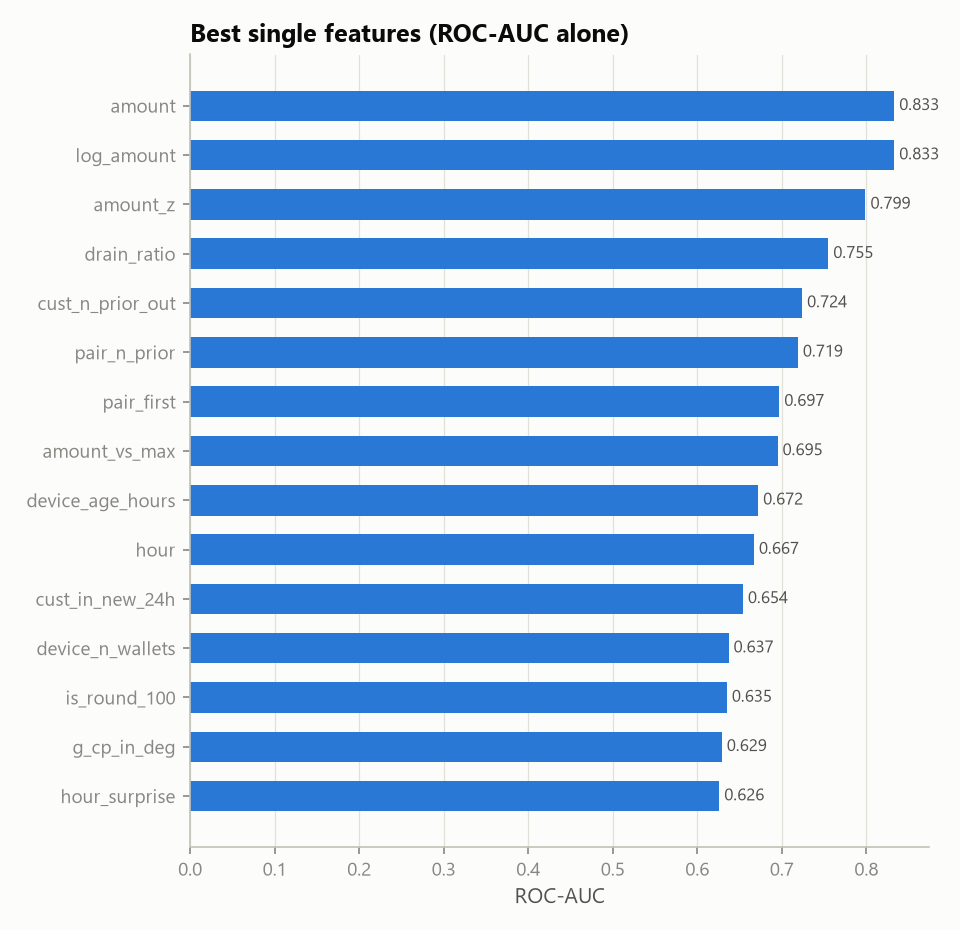

In [5]:
from sklearn.metrics import roc_auc_score
y = S.is_fraud.values
auc = {f: max(a, 1 - a) for f in ALL_FEATURES for a in [roc_auc_score(y, S[f].fillna(-999).values)]}
top = pd.Series(auc).sort_values(ascending=False).head(15).round(3)
plots.hbar(top.to_dict(), REPORTS / "figures" / "univariate_auc.png", "Best single features (ROC-AUC alone)", "ROC-AUC", fmt="{:.3f}")
display(Image(filename=str(REPORTS / "figures" / "univariate_auc.png")))

## What a collector wallet looks like to the counterparty features

In [6]:
f = S[S.txn_type == "SEND_MONEY"]
g = f.assign(kind=np.where(f.is_fraud == 1, "fraud: " + f.scenario, "legit"))
g.groupby("kind")[["cp_age_days", "cp_in_new_24h", "pair_first", "amount_z", "device_age_hours", "chain_depth"]].median().round(2)

,cp_age_days,cp_in_new_24h,pair_first,amount_z,device_age_hours,chain_depth
kind,,,,,,
fraud: S1,55.10,0.0,1.0,1.04,0.01,0.0
fraud: S2,2.04,7.0,1.0,1.10,665.49,0.0
fraud: S3,43.39,0.0,1.0,2.14,121.92,2.0
fraud: S5,46.28,1.0,1.0,1.35,696.13,0.0
fraud: S6,49.17,0.0,1.0,1.97,0.19,0.0
fraud: S7,74.83,0.0,1.0,2.03,488.08,0.0
fraud: S8,29.59,0.0,1.0,1.57,99.35,1.0
legit,273.97,0.0,1.0,0.30,559.24,0.0
